### Step 1: Import Libraries

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [62]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn import metrics

In [36]:
import tensorflow as tf
from tensorflow import data
from tensorflow.keras import layers, Model, utils, callbacks, optimizers

In [5]:
import albumentations as A

### Step 2: Constant

In [23]:
AUTO = data.experimental.AUTOTUNE
DATA_FOLD = './data/lung_colon_image_set/lung_image_sets/'
IMG_HEIGH = 256
IMG_WIDTH = 256
IMG_CHANNEL = 3
BATCH_SIZE = 64
EPOCHS = 20
NUM_CLASSES = 3

### Step 3: Load Data

In [7]:
df = pd.DataFrame()
for label in os.listdir(DATA_FOLD):
    img_ids = os.listdir(f'{DATA_FOLD}{label}')
    temp = pd.DataFrame(
        {
            'img_id': os.listdir(f'{DATA_FOLD}{label}'),
            'label': label
        }
    )
    df = pd.concat([df, temp], axis=0, ignore_index=True)

In [8]:
df.sample(5)

,img_id,label
5006,lungn1003.jpeg,lung_n
1126,lungaca2011.jpeg,lung_aca
4386,lungaca4947.jpeg,lung_aca
11673,lungscc2504.jpeg,lung_scc
1290,lungaca216.jpeg,lung_aca


#### Step 4: Exploaring Data

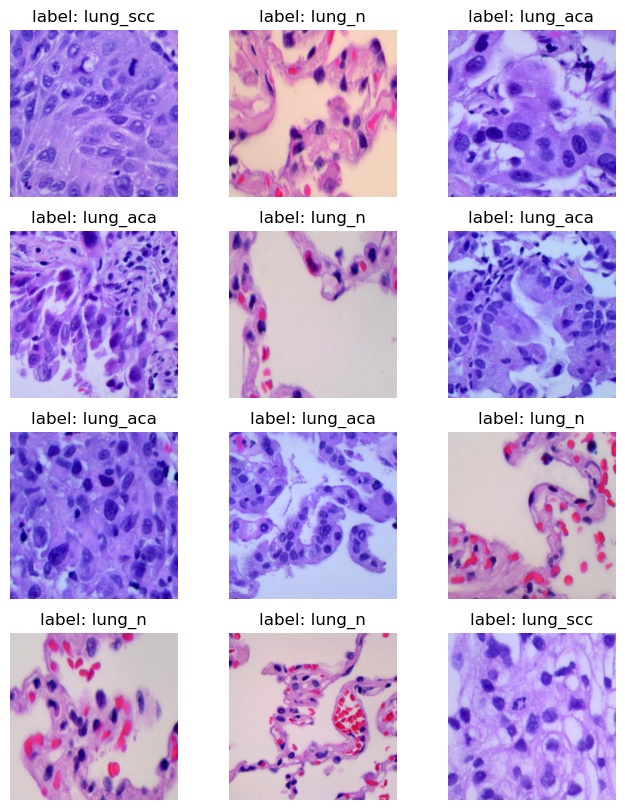

In [9]:
plt.figure(figsize=(8, 10))
for i in range(12):
    plt.subplot(4, 3, i+1)
    k = np.random.randint(df.shape[0])
    label = df.loc[k, 'label']
    img_id = df.loc[k, 'img_id']
    img = plt.imread(f'{DATA_FOLD}{label}/{img_id}')
    plt.imshow(img)
    plt.title(f'label: {label}')
    plt.axis('off')

### Step 5: Preparing Data

#### Label Encode

In [10]:
le = LabelEncoder()

In [11]:
df['label_id'] = le.fit_transform(df['label'])

#### Split Data

In [12]:
train, value = train_test_split(
    df,
    test_size=0.4,
    random_state=42
)

In [13]:
value, test = train_test_split(
    value,
    test_size=0.5,
    random_state=42
)

#### Albumentation

In [14]:
transform_train = A.Compose(
    [
        A.Resize(IMG_HEIGH, IMG_WIDTH),
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.5),
        A.RandomGamma(p=0.2),
        A.RandomBrightnessContrast(p=0.2),
        A.CoarseDropout(p=0.2)
    ]
)

In [15]:
transform_test = A.Resize(IMG_HEIGH, IMG_WIDTH)

#### Build Generator

In [27]:
def generator(df, img_shape, is_train):
    def gen():
        for _, row in df.iterrows():
            img_id = row['img_id']
            label = row['label']
            label_id = row['label_id']
            img = cv2.imread(f'{DATA_FOLD}{label}/{img_id}')
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            if is_train:
                img = transform_train(image=img)['image']
            else:
                img = transform_test(image=img)['image']
            img = img.astype('float32') / 255.0
            yield img, label_id

    return data.Dataset.from_generator(
        gen,
        output_signature=(
            tf.TensorSpec(shape=img_shape, dtype=tf.float32),
            tf.TensorSpec(shape=(), dtype=tf.uint8)
        )
    )

In [33]:
def get_generator(df, img_shape, batch_size, is_train=True):
    gen = generator(df, img_shape, is_train=is_train)
    gen = gen.map(
        lambda x, y: (x, tf.one_hot(y, NUM_CLASSES))
    )
    if is_train:
        gen = gen.shuffle(min(len(df), 1000))
    gen = gen.batch(batch_size)
    gen = gen.prefetch(AUTO)
    return gen

In [34]:
train_generator = get_generator(train, (IMG_HEIGH, IMG_WIDTH, IMG_CHANNEL), BATCH_SIZE)
value_generator = get_generator(value, (IMG_HEIGH, IMG_WIDTH, IMG_CHANNEL), BATCH_SIZE, is_train=False)
test_generator = get_generator(test, (IMG_HEIGH, IMG_WIDTH, IMG_CHANNEL), BATCH_SIZE, is_train=False)

In [35]:
for img, label in train_generator.take(1):
    print(img.shape, label.shape)

(64, 256, 256, 3) (64, 3)


### Step 6: Model Development

#### Build Model

In [44]:
inputs = layers.Input(shape=(IMG_HEIGH, IMG_WIDTH, IMG_CHANNEL))
x = layers.Conv2D(32, kernel_size=5, activation='relu', padding='same')(inputs)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D()(x)
x = layers.Conv2D(64, kernel_size=3, activation='relu', padding='same')(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D()(x)
x = layers.Conv2D(128, kernel_size=3, activation='relu', padding='same')(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D()(x)
x = layers.Conv2D(256, kernel_size=3, activation='relu', padding='same')(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D()(x)
x = layers.Conv2D(512, kernel_size=3, activation='relu', padding='same')(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D()(x)
x = layers.Flatten()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.5)(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

In [45]:
model = Model(inputs, outputs)

In [46]:
model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)           │ (None, 256, 256, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_7 (Conv2D)                    │ (None, 256, 256, 32)        │           2,432 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_11               │ (None, 256, 256, 32)        │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_7 (MaxPooling2D)       │ (None, 128, 128, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_8 (Conv2D)                    │ (None, 128, 128, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_12               │ (None, 128, 128, 64)        │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_8 (MaxPooling2D)       │ (None, 64, 64, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_9 (Conv2D)                    │ (None, 64, 64, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_13               │ (None, 64, 64, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_9 (MaxPooling2D)       │ (None, 32, 32, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_10 (Conv2D)                   │ (None, 32, 32, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_14               │ (None, 32, 32, 256)         │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_10 (MaxPooling2D)      │ (None, 16, 16, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_11 (Conv2D)                   │ (None, 16, 16, 512)         │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_15               │ (None, 16, 16, 512)         │           2,048 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_11 (MaxPooling2D)      │ (None, 8, 8, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_2 (Flatten)                  │ (None, 32768)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 256)                 │       8,388,864 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_16               │ (None, 256)                 │           1,0

 Total params: 9,997,763 (38.14 MB)

 Trainable params: 9,995,011 (38.13 MB)

 Non-trainable params: 2,752 (10.75 KB)

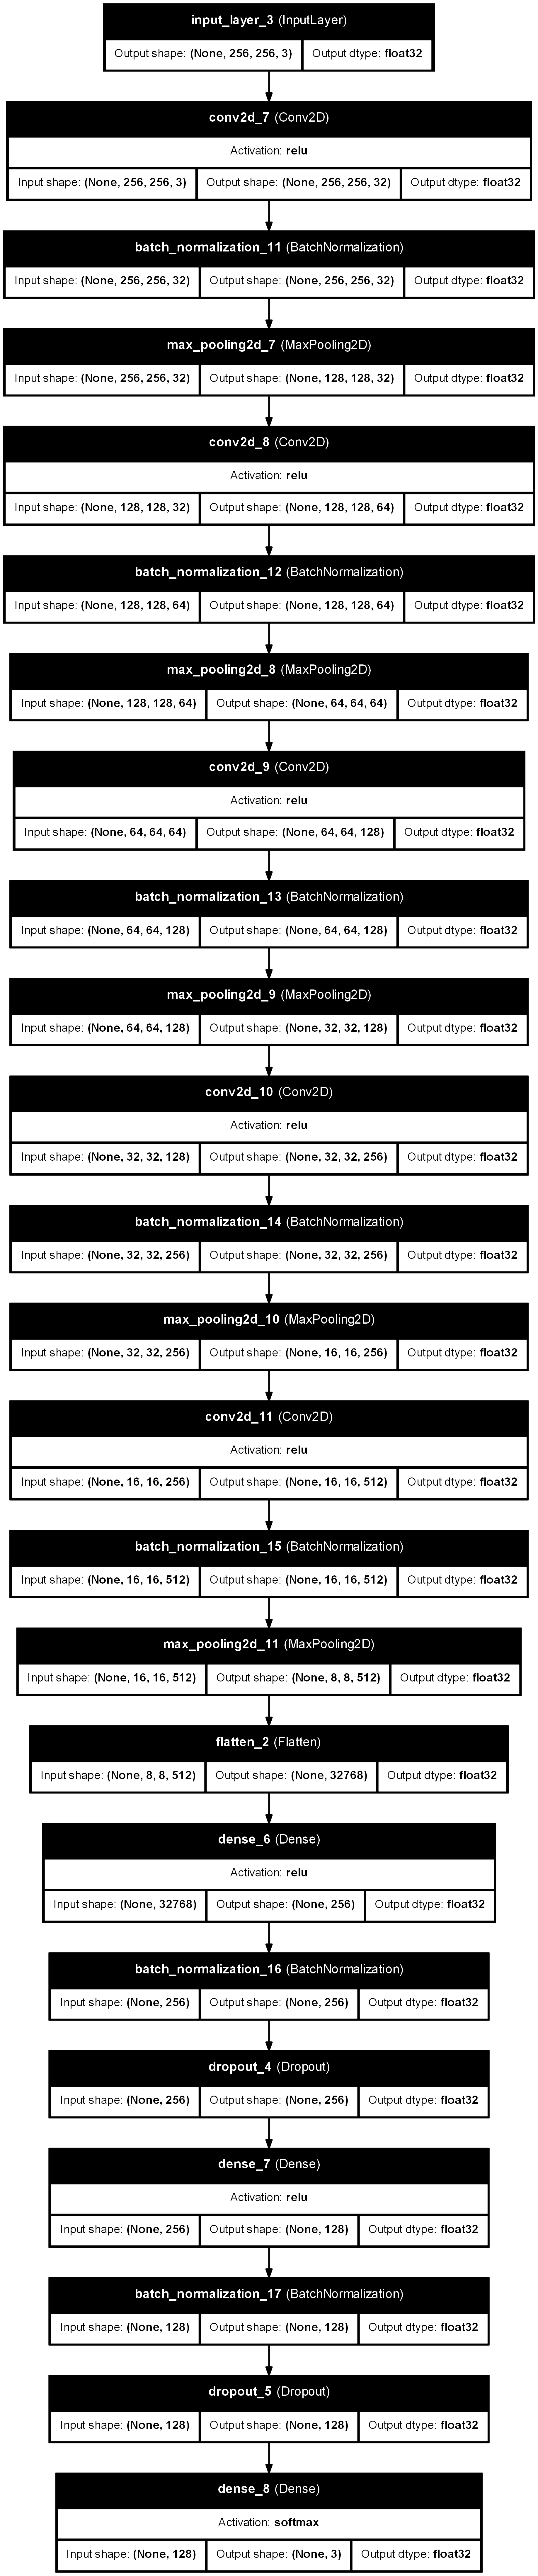

In [48]:
utils.plot_model(
    model,
    show_shapes=True,
    show_dtype=True,
    show_layer_names=True,
    show_layer_activations=True
)

#### Compile Model

In [49]:
optimizer = optimizers.Adam(0.001, clipnorm=1.0)

In [50]:
model.compile(
    loss='categorical_crossentropy',
    optimizer=optimizer,
    metrics=['accuracy']
)

#### Train Model

In [51]:
early_stopping = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    verbose=0,
    restore_best_weights=True
)

In [52]:
lr_schedule = callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    verbose=0
)

In [53]:
history = model.fit(
    train_generator,
    validation_data=value_generator,
    epochs=EPOCHS,
    callbacks=[early_stopping, lr_schedule]
)

Epoch 1/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 384s 3s/step - accuracy: 0.8543 - loss: 0.4088 - val_accuracy: 0.6450 - val_loss: 0.7639 - learning_rate: 0.0010
Epoch 2/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 381s 3s/step - accuracy: 0.9034 - loss: 0.2535 - val_accuracy: 0.3470 - val_loss: 3.6023 - learning_rate: 0.0010
Epoch 3/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 382s 3s/step - accuracy: 0.9233 - loss: 0.2038 - val_accuracy: 0.3440 - val_loss: 4.1771 - learning_rate: 0.0010
Epoch 4/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 372s 3s/step - accuracy: 0.9334 - loss: 0.1720 - val_accuracy: 0.9053 - val_loss: 0.2243 - learning_rate: 0.0010
Epoch 5/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 370s 3s/step - accuracy: 0.9504 - loss: 0.1309 - val_accuracy: 0.9100 - val_loss: 0.2725 - learning_rate: 0.0010
Epoch 6/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 371s 3s/step - accuracy: 0.9540 - loss: 0.1225 - val_accuracy: 0.8083 - val_loss: 0.5979 - learning_rate: 0.0010
Epoch 7/20
141/141 ━━━━━━━━━━━━━━━━━━━━ 370s 3s/step - accuracy: 0.9582 - loss: 0.

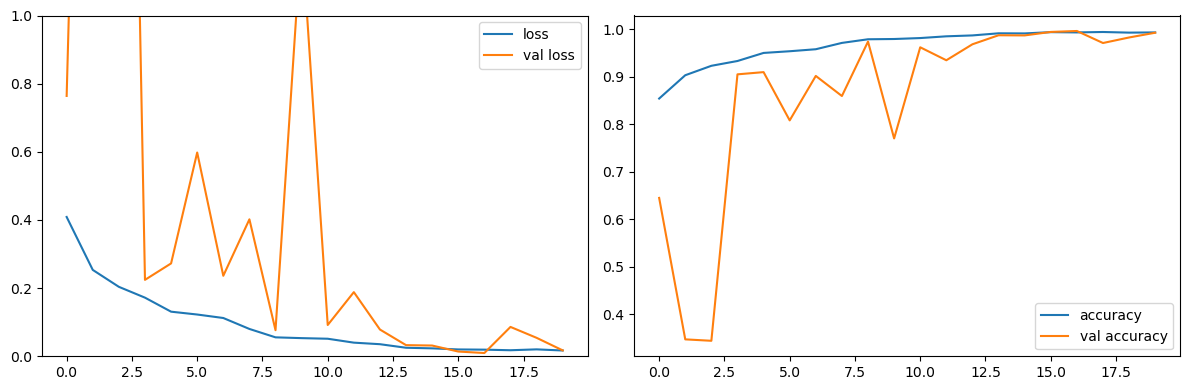

In [59]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.ylim(0, 1)
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label='val accuracy')
plt.legend()
plt.tight_layout()

#### Evaluate Model

In [60]:
loss, accuracy = model.evaluate(test_generator, verbose=0)
print(f'test loss: {round(loss, 3)}, test accuracy: {round(accuracy, 3)}')

test loss: 0.006, test accuracy: 0.998


In [61]:
test_pred = model.predict(test_generator)

47/47 ━━━━━━━━━━━━━━━━━━━━ 25s 525ms/step


In [64]:
test

,img_id,label,label_id
9502,lungn550.jpeg,lung_n,1
1851,lungaca2665.jpeg,lung_aca,0
5933,lungn1839.jpeg,lung_n,1
12171,lungscc2953.jpeg,lung_scc,2
7342,lungn3106.jpeg,lung_n,1
...,...,...,...
6545,lungn239.jpeg,lung_n,1
11566,lungscc2408.jpeg,lung_scc,2
10959,lungscc1862.jpeg,lung_scc,2
1744,lungaca2569.jpeg,lung_aca,0


In [66]:
confuse_matrix = metrics.confusion_matrix(test['label_id'], np.argmax(test_pred, axis=1))

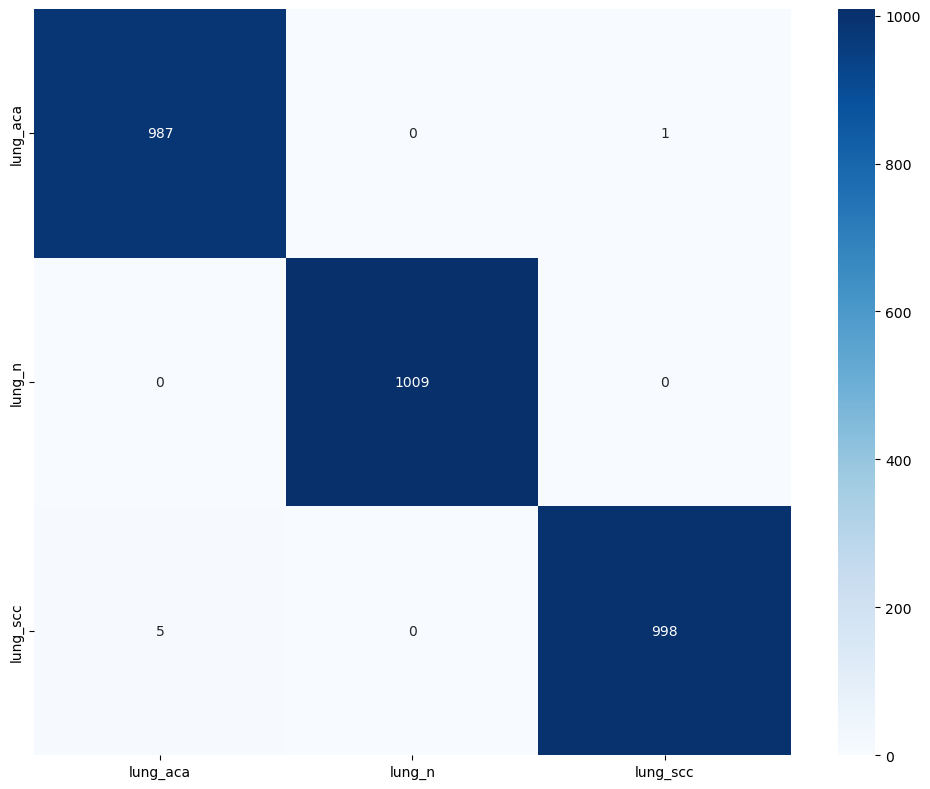

In [69]:
plt.figure(figsize=(10, 8))
sns.heatmap(
    confuse_matrix,
    fmt='d',
    annot=True,
    cmap=plt.cm.Blues,
    xticklabels=le.classes_,
    yticklabels=le.classes_
)
plt.tight_layout()